In [1]:
#Instalaciones básicas
import pandas as pd
import sys
sys.path.append("..")
import openpyxl 
from src import soporte as sp
import re

#Instalaciones de visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
#Abrimos el archivo limpio
df = pd.read_csv("../data/data_para_KPIS.csv", parse_dates=['date'])

# Calculamos KPIS

In [3]:
### 1. Tasa de Conversión ###
conversion_rate = (df['y'].value_counts(normalize=True) * 100)
print("Tasa de Conversión:\n", conversion_rate)

Tasa de Conversión:
 y
no     88.734884
yes    11.265116
Name: proportion, dtype: float64


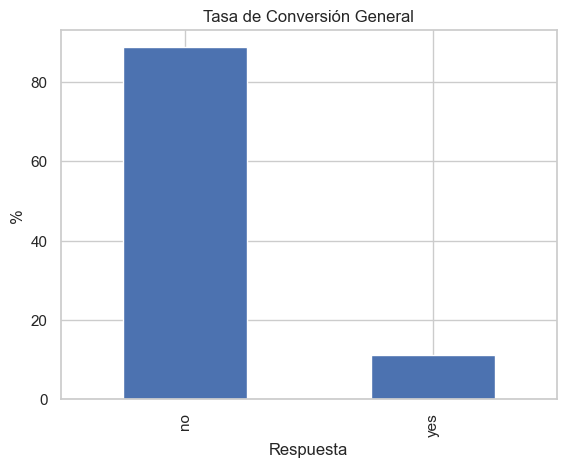

In [4]:
conversion_rate = df['y'].value_counts(normalize=True) * 100
conversion_rate.plot(kind='bar', title='Tasa de Conversión General')
plt.ylabel('%')
plt.xlabel('Respuesta')
plt.show()

Conclusión:  Valor de conversión  bajo, indica que la campaña necesita una revisión profunda. Puede ser que el enfoque no esté funcionando o que el público objetivo no esté bien segmentado.

Duración media de la llamada: 257.74 segundos
       count        mean         std   min    25%    50%    75%     max
y                                                                      
no   38156.0  220.430208  207.121495   0.0   95.0  163.0  278.0  4918.0
yes   4844.0  551.621387  398.398264  63.0  253.0  449.0  740.0  4199.0


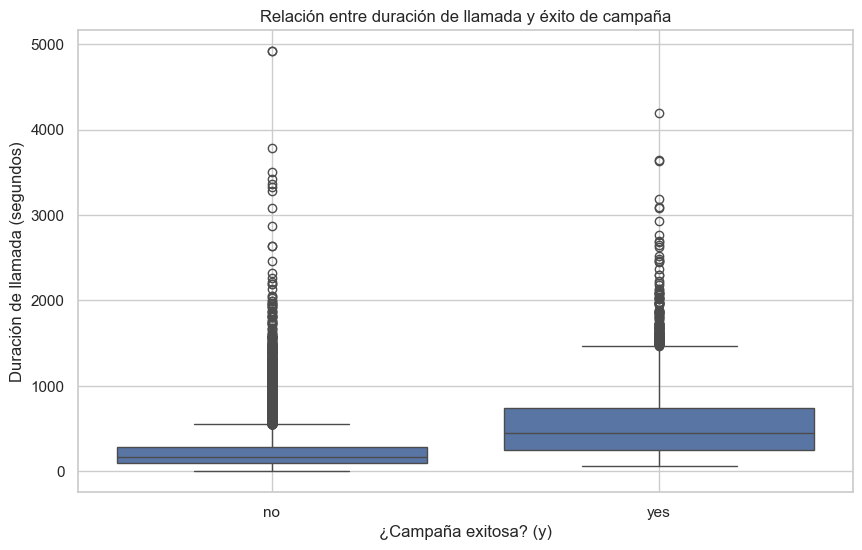

In [5]:
### 2. Duración Media de la Llamada ###
avg_call_duration = df["duration"].mean()
print(f"Duración media de la llamada: {avg_call_duration:.2f} segundos")
# Estadísticas descriptivas por clase de "y"
print(df.groupby("y")["duration"].describe())

# Boxplot para visualizar la distribución de la duración por tipo de respuesta
plt.figure(figsize=(10, 6))
sns.boxplot(x="y", y="duration", data=df)
plt.title("Relación entre duración de llamada y éxito de campaña")
plt.xlabel("¿Campaña exitosa? (y)")
plt.ylabel("Duración de llamada (segundos)")
plt.grid(True)
plt.show()

Existe una relación positiva entre la duración de la llamada y el éxito de la campaña. Específicamente:

Las llamadas asociadas a campañas exitosas (y = yes) son considerablemente más largas en promedio (media ≈ 552 segundos) en comparación con las llamadas de campañas no exitosas (media ≈ 220 segundos).

La mediana también muestra esta diferencia clara: 449 segundos para campañas exitosas vs. 163 segundos para las no exitosas.

El rango intercuartílico de las campañas exitosas está desplazado hacia valores más altos, indicando que incluso las llamadas "típicas" (sin contar los extremos) son más largas cuando la campaña resulta exitosa.

Hay más variabilidad en la duración de llamadas exitosas, lo cual puede indicar que, aunque la tendencia es hacia mayor duración, hay distintos perfiles de éxito.



In [6]:
### 3. Número Promedio de Contactos por Cliente ###
avg_contacts_per_client = df["campaign"].mean()
print(f"Número promedio de contactos por cliente: {avg_contacts_per_client:.2f}")

Número promedio de contactos por cliente: 2.57


       count      mean       std  min  25%  50%  75%   max
y                                                         
no   38156.0  2.632797  2.876537  1.0  1.0  2.0  3.0  56.0
yes   4844.0  2.050784  1.657519  1.0  1.0  2.0  2.0  23.0

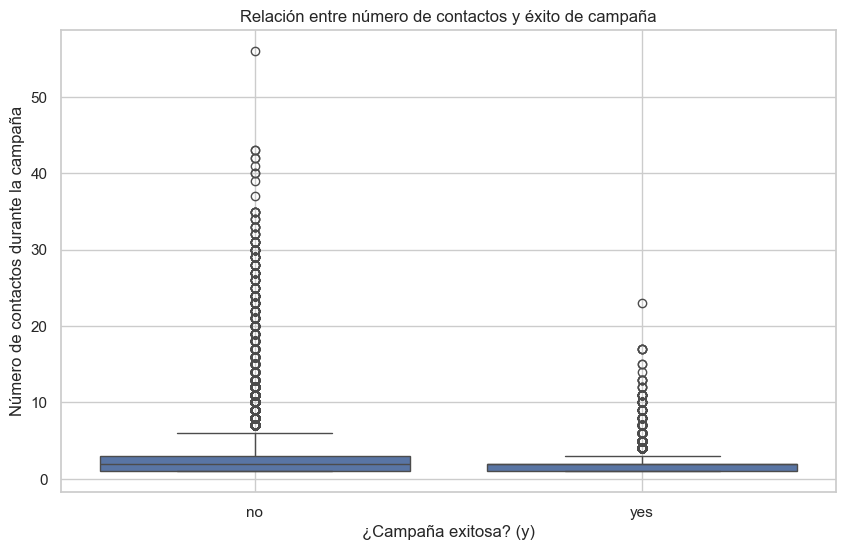


Número medio de contactos por grupo:
y
no     2.632797
yes    2.050784
Name: campaign, dtype: float64


In [7]:
# Estadísticas descriptivas por clase de "y"
print(df.groupby("y")["campaign"].describe())

# Boxplot para visualizar la distribución del número de contactos por tipo de respuesta
plt.figure(figsize=(10, 6))
sns.boxplot(x="y", y="campaign", data=df)
plt.title("Relación entre número de contactos y éxito de campaña")
plt.xlabel("¿Campaña exitosa? (y)")
plt.ylabel("Número de contactos durante la campaña")
plt.grid(True)
plt.show()

# Promedio de contactos por grupo
print("\nNúmero medio de contactos por grupo:")
print(df.groupby("y")["campaign"].mean())

Las campañas no exitosas promedian 2.63 contactos, mientras que las exitosas requieren, en promedio, solo 2.05 contactos para lograr el objetivo.

Esto representa una diferencia significativa en términos de eficiencia: las campañas exitosas requieren menos intentos de contacto para convertir a un cliente.

La dispersión también es considerablemente mayor en campañas no exitosas (desvío estándar de 2.88 frente a 1.66), lo cual sugiere un mayor grado de insistencia sin retorno positivo.

Además, el valor máximo de intentos en campañas fallidas (56) es más del doble del de las exitosas (23), lo que refuerza la idea de que un número elevado de contactos podría reflejar ineficiencia comercial o baja receptividad del cliente.

También es curiosos que la duración mínima de las llamadas es 0 mientras que el número de contactos mínimos es 1, lo cual nos lleva a que se han producido llamadas que no se han descolgado



In [8]:
### 4. Éxito por Método de Contacto ###
print(df.groupby("contact")["y"].describe())
contact_success = df.groupby("contact")["y"].value_counts(normalize=True).unstack() * 100
print("\nÉxito por método de contacto:\n", contact_success)

           count unique top   freq
contact                           
cellular   27396      2  no  23357
telephone  15604      2  no  14799

Éxito por método de contacto:
 y                 no        yes
contact                        
cellular   85.256972  14.743028
telephone  94.841066   5.158934


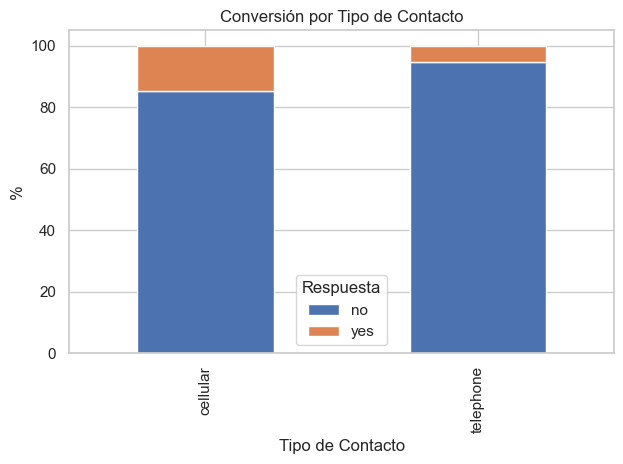

In [9]:
contact_type = df.groupby('contact')['y'].value_counts(normalize=True).unstack() * 100
contact_type.plot(kind='bar', stacked=True, title='Conversión por Tipo de Contacto')
plt.ylabel('%')
plt.xlabel('Tipo de Contacto')
plt.legend(title='Respuesta')
plt.tight_layout()
plt.show()

Conclusión: Generalmente, el celular muestra mejor desempeño. Las campañas deberían optimizarse para este medio.

In [10]:
### 5. Efectividad según Educación ###
print(df.groupby("education")["y"].value_counts())
education_success = df.groupby("education")["y"].value_counts(normalize=True).unstack() * 100
print("\nTasa de éxito según nivel educativo:\n", education_success)

education            y  
basic                no     11916
                     yes     1135
high.school          no      8849
                     yes     1076
illiterate           no        14
                     yes        4
professional.course  no      4857
                     yes      620
university.degree    no     10974
                     yes     1748
unknown              no      1546
                     yes      261
Name: count, dtype: int64

Tasa de éxito según nivel educativo:
 y                           no        yes
education                                
basic                91.303348   8.696652
high.school          89.158690  10.841310
illiterate           77.777778  22.222222
professional.course  88.679934  11.320066
university.degree    86.260022  13.739978
unknown              85.556170  14.443830


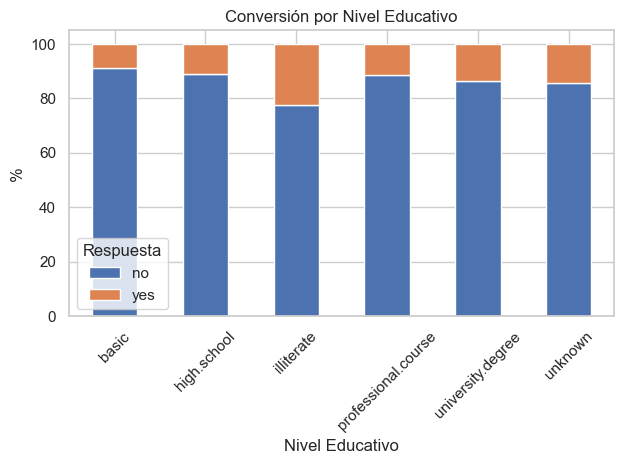

In [11]:
education_success = df.groupby("education")["y"].value_counts(normalize=True).unstack() * 100
education_success.plot(kind='bar', stacked=True, title='Conversión por Nivel Educativo')
plt.ylabel('%')
plt.xlabel('Nivel Educativo')
plt.xticks(rotation=45)
plt.legend(title='Respuesta')
plt.tight_layout()
plt.show()

Conclusión: Aunque a priori el grupo de analfabetos parezca tener una gran dominancia en los "SÍ" se trata de una muestra muy pequeña y por lo tanto no represenatativa. Del resto de datos se puede observar una mayor cantidad de gente que opta por contratar el produncto cuan mayor es su eduación pero sin ser muy amplia la diferencia

In [12]:
### 6. Clientes con Créditos Activos ###
print(df.groupby(["housing", "loan"])["y"].value_counts())
credit_impact = df.groupby(["housing", "loan"])["y"].value_counts(normalize=True).unstack() * 100
print("\nImpacto de créditos en la conversión:\n", credit_impact)

housing  loan  y  
no       no    no     14965
               yes     1825
         yes   no      2397
               yes      289
unknown  no    no       912
               yes      114
yes      no    no     16460
               yes     2192
         yes   no      3422
               yes      424
Name: count, dtype: int64

Impacto de créditos en la conversión:
 y                    no        yes
housing loan                      
no      no    89.130435  10.869565
        yes   89.240506  10.759494
unknown no    88.888889  11.111111
yes     no    88.247909  11.752091
        yes   88.975559  11.024441


Conclusión: Podemos observar una pequeña conversión mayor en los que tienen una hipoteca e inversamente con los que tienen algún otro tipo de préstamo.

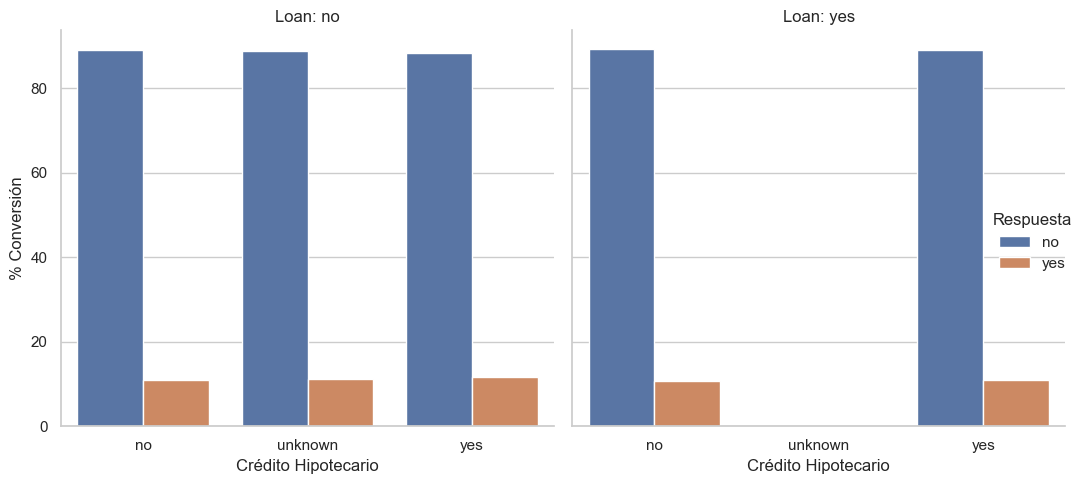

In [13]:
# KPI 6 - Impacto de créditos (housing y loan) en la conversión
credit_impact = df.groupby(["housing", "loan"])["y"].value_counts(normalize=True).unstack() * 100

# Convertir a formato plano para graficar
credit_impact_reset = credit_impact.reset_index().melt(id_vars=["housing", "loan"], var_name="Respuesta", value_name="Porcentaje")

# Crear gráfico con subplots por tipo de crédito personal (loan)
g = sns.catplot(
    data=credit_impact_reset,
    x="housing", y="Porcentaje", hue="Respuesta", col="loan",
    kind="bar", height=5, aspect=1
)
g.set_titles("Loan: {col_name}")
g.set_axis_labels("Crédito Hipotecario", "% Conversión")
g._legend.set_title("Respuesta")
plt.tight_layout()
plt.show()


In [14]:
### 7. Relación entre Ingresos y Conversión en grupos de similar cantidad###
if "income" in df.columns:
    income_conversion = df.groupby(pd.cut(df["income"], bins=5))["y"].value_counts(normalize=True).unstack() * 100
    print("\nConversión por nivel de ingreso:\n", income_conversion)


Conversión por nivel de ingreso:
 y                            no        yes
income                                    
(5666.039, 40833.2]   88.670065  11.329935
(40833.2, 75825.4]    88.556809  11.443191
(75825.4, 110817.6]   88.418343  11.581657
(110817.6, 145809.8]  88.948818  11.051182
(145809.8, 180802.0]  89.079582  10.920418


C:\Users\cargo\AppData\Local\Temp\ipykernel_19008\2443153000.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_conversion = df.groupby(pd.cut(df["income"], bins=5))["y"].value_counts(normalize=True).unstack() * 100


C:\Users\cargo\AppData\Local\Temp\ipykernel_19008\711720574.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_conversion = df.groupby(income_bins)["y"].value_counts(normalize=True).unstack() * 100


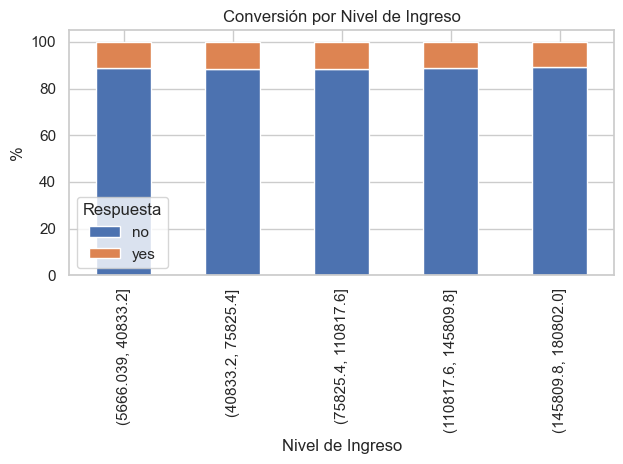

In [15]:
if "income" in df.columns:
    income_bins = pd.cut(df["income"], bins=5)
    income_conversion = df.groupby(income_bins)["y"].value_counts(normalize=True).unstack() * 100
    income_conversion.plot(kind='bar', stacked=True, title='Conversión por Nivel de Ingreso')
    plt.ylabel('%')
    plt.xlabel('Nivel de Ingreso')
    plt.legend(title='Respuesta')
    plt.tight_layout()
    plt.show()

Conclusión: Observamos una mayor conversión dentro del grupo central (75825.4- 110817.6) y una ligera bajada según nos acercamos a ambos extremos.

In [16]:
### 8. Conversión entre contactos recientes ###

df['recent_contact'] = df['pdays'].apply(lambda x: 'Reciente (<100)' if x < 100 else 'No reciente (>=100)')
print(df.groupby("recent_contact")["y"].describe())

print("----------------------------------------------------------")

conversion_by_contact_time = df.groupby('recent_contact')['y'].value_counts(normalize=True).unstack()
print("Conversión por Contacto Reciente:\n", conversion_by_contact_time)




                     count unique  top   freq
recent_contact                               
No reciente (>=100)  41412      2   no  37585
Reciente (<100)       1588      2  yes   1017
----------------------------------------------------------
Conversión por Contacto Reciente:
 y                          no       yes
recent_contact                         
No reciente (>=100)  0.907587  0.092413
Reciente (<100)      0.359572  0.640428


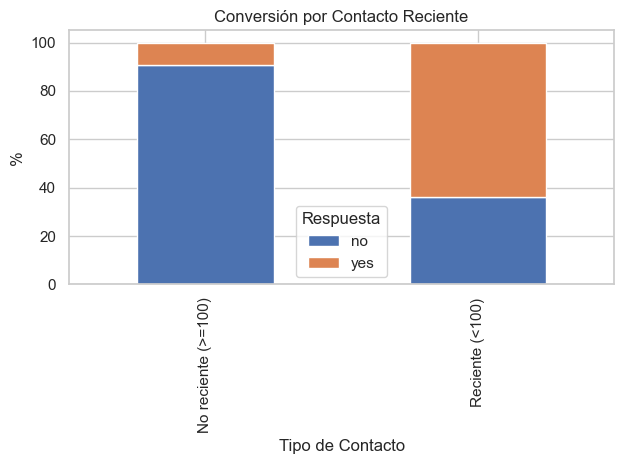

In [17]:
df['recent_contact'] = df['pdays'].apply(lambda x: 'Reciente (<100)' if x < 100 else 'No reciente (>=100)')
contact_conversion = df.groupby('recent_contact')['y'].value_counts(normalize=True).unstack() * 100
contact_conversion.plot(kind='bar', stacked=True, title='Conversión por Contacto Reciente')
plt.ylabel('%')
plt.xlabel('Tipo de Contacto')
plt.legend(title='Respuesta')
plt.tight_layout()
plt.show()

Conclusión: Existe una amplia tasa de aceptación dentro del grupo que fue contactado recientemente. Mientras que el grupo de los "no recientes" apenas consiguen conversión.
Aunque solo se contactó al 6% de la población, ese pequeño grupo tuvo una tasa de conversión muchísimo más alta (60% vs 9%). Eso no significa que ese 6% sea representativo, pero sí sugiere fuertemente que la campaña tuvo un gran efecto.

In [18]:
### 9. Relación entre la campaña anterior y conversión ###
print(df.groupby("poutcome")["y"].describe())
conversion_by_poutcome = df.groupby('poutcome')['y'].value_counts(normalize=True).unstack()
print("\nConversión por Resultado de Campaña Previa (poutcome):\n", conversion_by_poutcome)

             count unique  top   freq
poutcome                             
failure       4461      2   no   3826
nonexistent  37103      2   no  33832
success       1436      2  yes    938

Conversión por Resultado de Campaña Previa (poutcome):
 y                  no       yes
poutcome                       
failure      0.857655  0.142345
nonexistent  0.911840  0.088160
success      0.346797  0.653203


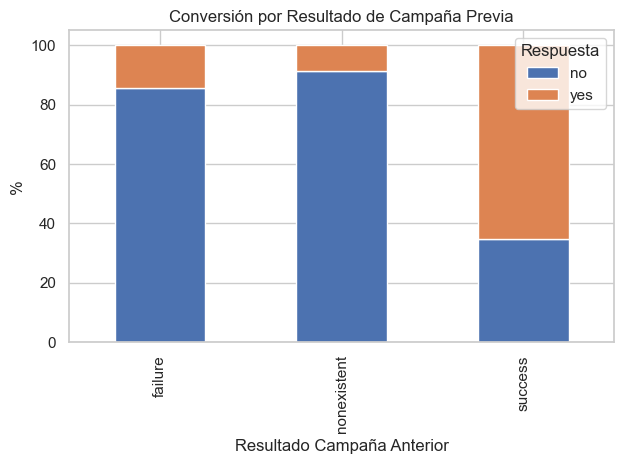

In [19]:
poutcome_conv = df.groupby('poutcome')['y'].value_counts(normalize=True).unstack() * 100
poutcome_conv.plot(kind='bar', stacked=True, title='Conversión por Resultado de Campaña Previa')
plt.ylabel('%')
plt.xlabel('Resultado Campaña Anterior')
plt.legend(title='Respuesta')
plt.tight_layout()
plt.show()

Conclución: Se puede observar una gran conversión dentro del segmento que tuvo éxito en la campaña previa. Todo lo contrario a cuando no se tuvo, ya sea porque fracaso o porque no existió.
Aunque dicha muestra de los que tuvieron éxito no es muy grande también se puede obervar una mayor conversión dentro del "failure" que dentro del "nonexistant" por lo que se recomienda contactar con los clientes en las campañas

In [20]:
### 10. Conversión por grupo de edad
print(df.groupby("age_group")["y"].describe())
conversion_by_age_group = df.groupby('age_group')['y'].value_counts(normalize=True).unstack()
print("\nConversión por Grupo de Edad:\n", conversion_by_age_group)

                count unique top   freq
age_group                              
Adulto (30-60)  37329      2  no  33510
Joven (<30)      5266      2  no   4417
Mayor (>60)       405      2  no    229

Conversión por Grupo de Edad:
 y                     no       yes
age_group                         
Adulto (30-60)  0.897693  0.102307
Joven (<30)     0.838777  0.161223
Mayor (>60)     0.565432  0.434568


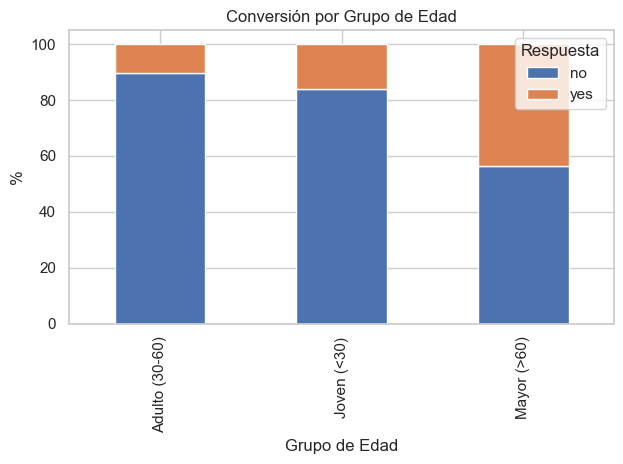

In [21]:
if 'age_group' not in df.columns:
    bins = [0, 30, 40, 50, 60, 100]
    labels = ['<30', '30-40', '40-50', '50-60', '60+']
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_conversion = df.groupby('age_group')['y'].value_counts(normalize=True).unstack() * 100
age_conversion.plot(kind='bar', stacked=True, title='Conversión por Grupo de Edad')
plt.ylabel('%')
plt.xlabel('Grupo de Edad')
plt.legend(title='Respuesta')
plt.tight_layout()
plt.show()

Conclusión: Pese a no ser un segmento muy significativo si que existe un porcentaje muy interesante de conversión dentro del grupo de mayores lo cual podría ser un segmento muy interesante a contactar más en el futuro

In [22]:
### 11. Relación entre estado civil y conversión ###
print(df.groupby("marital")["y"].describe())
conversion_by_marital = df.groupby('marital')['y'].value_counts(normalize=True).unstack()
print("\nConversión por Estado Civil:\n", conversion_by_marital)

          count unique top   freq
marital                          
divorced   4811      2  no   4321
married   25999      2  no  23344
single    12105      2  no  10419
unknown      85      2  no     72

Conversión por Estado Civil:
 y               no       yes
marital                     
divorced  0.898150  0.101850
married   0.897881  0.102119
single    0.860719  0.139281
unknown   0.847059  0.152941


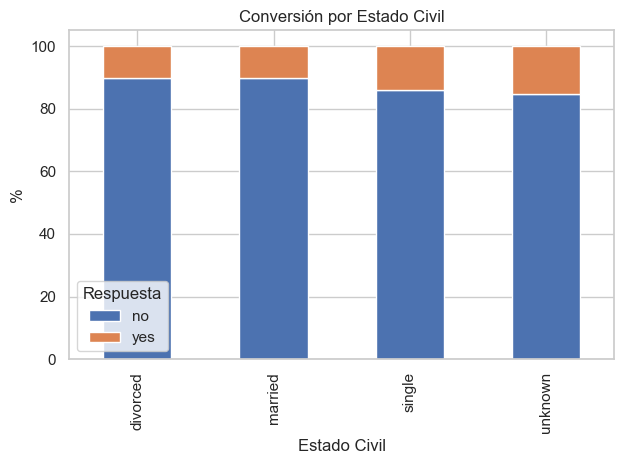

In [23]:
marital_conv = df.groupby('marital')['y'].value_counts(normalize=True).unstack() * 100
marital_conv.plot(kind='bar', stacked=True, title='Conversión por Estado Civil')
plt.ylabel('%')
plt.xlabel('Estado Civil')
plt.legend(title='Respuesta')
plt.tight_layout()
plt.show()

Conclusión: Obrservamos una ligera mayor conversión dentro del grupo de solteros